In [19]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec  #grid pels subplots
from matplotlib import colors         #colors
from matplotlib.colors import LogNorm   #normalitza a 0-1 en escala logarítmica 
from matplotlib import patches     #figures
from mpl_toolkits.mplot3d import Axes3D   #eixos en 3D
from mpl_toolkits.axes_grid1 import make_axes_locatable  #per canviar la posició dels eixos
from matplotlib.ticker import NullFormatter   #marques(tics) sense etiquetes en els eixos

from astroML.density_estimation import XDGMM
from astroML.plotting.tools import draw_ellipse
from astroML.crossmatch import crossmatch
from astroML.datasets import fetch_sdss_S82standards, fetch_imaging_sample
from astroML.stats import sigmaG
from astroML.utils.decorators import pickle_results
import os
import pickle

import astropy.table     #paquet per manejar taules de dades
from astropy.table import Table, Column, MaskedColumn   #importa taules, columnes i columnes que emmascaren dades invàlides
from astropy.visualization import astropy_mpl_style  #visualització 
from scipy.stats import gaussian_kde  #representation of a kernel-density estimate using Gaussian kernels.
import seaborn as sns  #llibreria per fer gràfics estadístics
import os.path   #per implementar diferents funcions amb pathnames ("dreceres")

from time import time   #mòdul de funcions de time access 
from sklearn import manifold, datasets #manifold: algoritme de dimensionality reduction 
                                       #sklearn (sci-kit learn): llibreria de Python per machine learning
import umap                #Uniform Manifold Approximation and Projection (UMAP) is a dimensionality reduction technique
from sklearn.decomposition import PCA  #Principal component analysis (PCA). Linear dimensionality reduction using Singular Value    
from sklearn.manifold import TSNE #t-SNE [1] is a tool to visualize high-dimensional data
from itertools import product   #producte cartesià

import obtain_data   #per importar dades d'altres fitxers

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=16, usetex=True)

### Preparing the sample (mostra de RedClumps)
#### The GALAH DR3 RC sample
The GALAH DR3 red-clump sample is a selection of RC stars from the GALAH DR3 catalogue. I have put together the possibly interesting portions of the catalogs and cut a sample of red clump (RC) stars using topcat: (teff > 4500 && teff < 5100 && logg > 2.3 && logg < 2.55 && is_redclump_bstep > 0.5). This sample contains 37,417 stars.

In [20]:
import importlib   #package per importar coses a python
importlib.reload(obtain_data)

galah_rc = obtain_data.galah_dr3_rc()   

### Prepare the input arrays for XD

In [21]:
galah_rc.get_ndimspace(feh=True, norm="stdev")

X = galah_rc.X            #(10941, 24)
Xerr = galah_rc.Xerr1         #(10941, 24)
Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
Xcov[:, range(Xerr.shape[1]), range(Xerr.shape[1])] = Xerr ** 2    #(10941, 24, 24)

Cal calcular una matriu W (mixture matrix)???  no pq errors d'un element no influeixen en errors d'un altre, en una mateixa estrella

@pickle_results: using precomputed results from 'XD_5clusters.pkl'
@pickle_results: using precomputed results from 'XD_10clusters.pkl'
@pickle_results: using precomputed results from 'XD_15clusters.pkl'
@pickle_results: using precomputed results from 'XD_20clusters.pkl'
@pickle_results: using precomputed results from 'XD_25clusters.pkl'


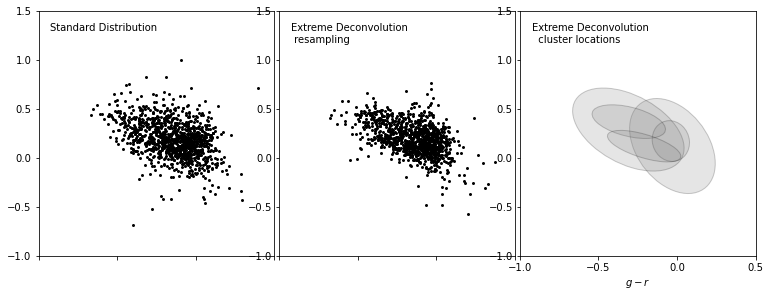

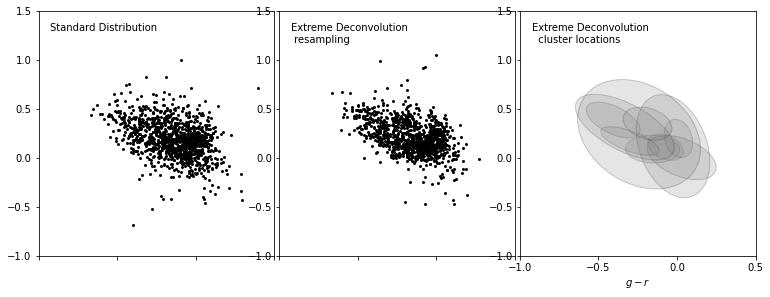

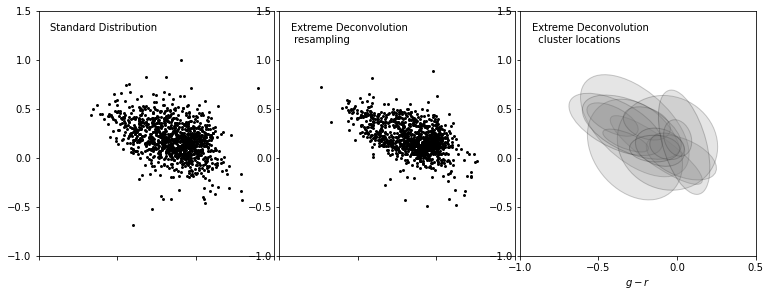

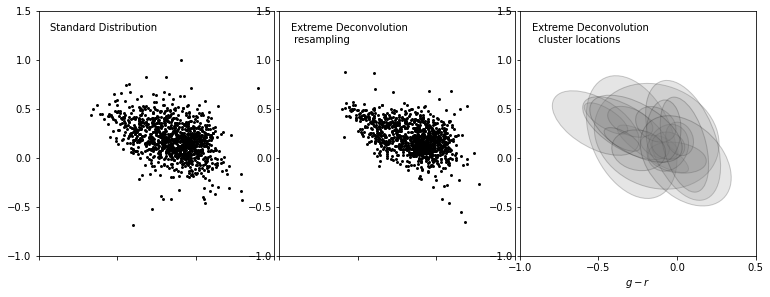

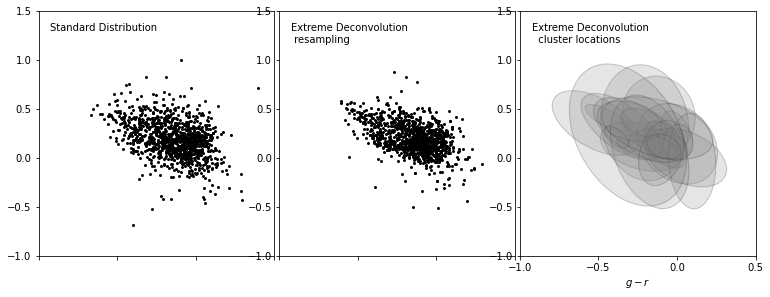

In [38]:
import corner 
for n_clusters in range(5, 26, 5):   
    @pickle_results('XD_'+str(n_clusters)+'clusters.pkl')
    def compute_XD(n_clusters=n_clusters, rseed=0, max_iter=100, verbose=True):
        np.random.seed(rseed)
        clf = XDGMM(n_clusters, max_iter=max_iter, tol=1E-5, verbose=verbose)
        clf.fit(X, Xcov) 
        return clf
    # Fit the model on training set
    clf = compute_XD(n_clusters)  #la primera vegada que es crida la funció ho guarda a l'arxiu pkl
    
    np.random.seed(42)

    #figure = corner.corner(np.array([galah_rc.data["R_Rzphi"],galah_rc.data["phi_Rzphi"], 
    #                                 galah_rc.data["z_Rzphi"]]).T, 
    #                       weights=None, bins=30, 
    #                       range=[[4,12],[-.5,0.5],[-2,2]],
    #                       labels=[r"$R_{\rm Gal}$ [kpc]", r"$\varphi$", 
    #                               r"$Z_{\rm Gal}$ [kpc]"],
    #                       quantiles=[0.16, 0.5, 0.84],plot_datapoints=False,
    #                       show_titles=False, label_kwargs={"fontsize": 20})
    #
    #     - plt.savefig("../im/corner_rphiz.png")
    

    # Fit and sample from the underlying distribution
    X_sample = clf.sample(X.shape[0])   #XD resampling X

    # plot the results
    fig = plt.figure(figsize=(12, 4))   #tamany de la figura
    fig.subplots_adjust(left=0.12, right=0.95,
                        bottom=0.1, top=0.95,
                        wspace=0.02, hspace=0.02)

    # only plot 1/10 of the stars for clarity
    #standard
    ax1 = fig.add_subplot(131)  #una fila, 3 columnes, posició 1
    ax1.scatter(X[::10, 0], X[::10, 1], s=9, lw=0, c='k')   #standard X (representa abundàncies 0 i 1)
    #XDeconvolution
    ax2 = fig.add_subplot(132)  #una fila, 3 columnes, posició 2
    ax2.scatter(X_sample[::10, 0], X_sample[::10, 1], s=9, lw=0, c='k')  #XD resampling X
    #elipses
    ax3 = fig.add_subplot(133)  #una fila, 3 columnes, posició 3
    for i in range(clf.n_components):
        draw_ellipse(clf.mu[i, 0:2], clf.V[i, 0:2, 0:2], scales=[2],
                     ec='k', fc='gray', alpha=0.2, ax=ax3)

    titles = ["Standard Distribution","Extreme Deconvolution\n resampling",
              "Extreme Deconvolution\n  cluster locations"]
    ax = [ax1, ax2, ax3]

    for i in range(3):
        ax[i].set_xlim(-1, 0.5)
        ax[i].set_ylim(-1, 1.5)

        ax[i].xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax[i].yaxis.set_major_locator(plt.MultipleLocator(0.5))

        ax[i].text(0.05, 0.95, titles[i],
                   ha='left', va='top', transform=ax[i].transAxes)

        if i in (0, 1):
            ax[i].xaxis.set_major_formatter(plt.NullFormatter())
        else:
            ax[i].set_xlabel('$g-r$')
            
    plt.savefig('../im/figXD_'+str(n_clusters)+'clusters.png')